In [1]:
import pip
pip.main(['install','seaborn'])

Please see https://github.com/pypa/pip/issues/5599 for advice on fixing the underlying issue.
To avoid this problem you can invoke Python with '-m pip' instead of running pip directly.


Requirement already satisfied: seaborn in /Users/uenakayuto/main-research/mycode/.myenv/lib/python3.12/site-packages (0.13.2)

Requirement already satisfied: numpy!=1.24.0,>=1.20 in /Users/uenakayuto/main-research/mycode/.myenv/lib/python3.12/site-packages (from seaborn) (2.0.1)

Requirement already satisfied: pandas>=1.2 in /Users/uenakayuto/main-research/mycode/.myenv/lib/python3.12/site-packages (from seaborn) (2.2.2)

Requirement already satisfied: matplotlib!=3.6.1,>=3.4 in /Users/uenakayuto/main-research/mycode/.myenv/lib/python3.12/site-packages (from seaborn) (3.9.1)

...

Requirement already satisfied: pytz>=2020.1 in /Users/uenakayuto/main-research/mycode/.myenv/lib/python3.12/site-packages (from pandas>=1.2->seaborn) (2024.1)

Requirement already satisfied: tzdata>=2022.7 in /Users/uenakayuto/main-research/mycode/.myenv/lib/python3.12/site-packages (from pandas>=1.2->seaborn) (2024.1)

Requirement already satisfied: six>=1.5 in /Users/uenakayuto/main-research/mycode/.myenv/lib/python3.12/site-packages (from python-dateutil>=2.7->matplotlib!=3.6.1,>=3.4->seaborn) (1.16.0)

[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: pip install --upgrade pip

0

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

In [3]:
df = pd.read_csv('features.csv')
df

,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,f_10,f_11
0,0.983333,0.000000,0.950000,0.898507,0.850000,0.983333,0.999447,0.893298,0.995338,0.985427,0.985371,0.998103
1,0.988889,0.000000,0.922222,0.887035,0.844444,0.966667,0.999898,0.100963,0.998922,0.978263,0.997494,0.999497
2,0.993377,0.000000,0.953642,0.906296,0.900662,0.973510,0.999774,0.175629,0.997442,0.963261,0.991693,0.999078
3,0.983333,0.000000,0.933333,0.846778,0.783333,0.983333,0.999772,0.202265,0.998067,0.969982,0.987613,0.999263
4,0.995238,0.004762,0.928571,0.897883,0.828571,0.985714,0.999955,0.359036,0.997262,0.993316,0.995656,0.998304
...,...,...,...,...,...,...,...,...,...,...,...,...
470,0.983333,0.000000,0.783333,0.723510,0.750000,0.966667,0.999931,0.255064,0.996291,0.983576,0.994528,0.998319
471,0.988889,0.000000,0.933333,0.765524,0.755556,0.977778,0.998461,0.796072,0.993332,0.979229,0.989234,0.995262
472,0.966667,0.000000,0.966667,0.780388,0.866667,0.966667,0.998372,0.764316,0.996551,0.987141,0.995244,0.997573
473,0.991667,0.000000,0.875000,0.742129,0.741667,0.958333,0.999958,0.216969,0.998153,0.971031,0.994132,0.999782


In [4]:
from sklearn.neighbors import NearestNeighbors # importing the library
neighb = NearestNeighbors(n_neighbors=2) # creating an object of the NearestNeighbors class, which can be same as the minPts value
nbrs=neighb.fit(df) # fitting the data to the object
distances,indices=nbrs.kneighbors(df)

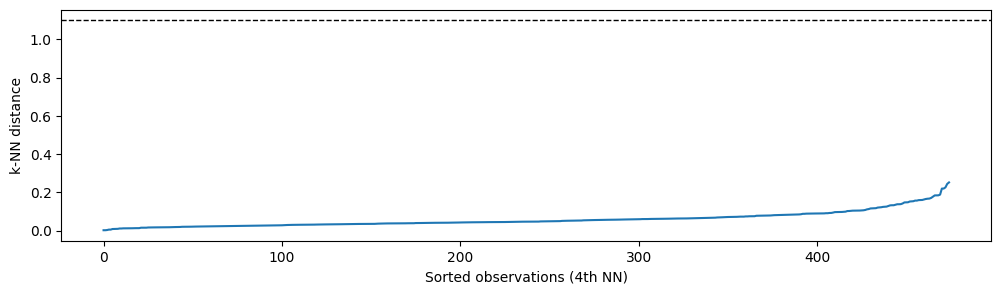

0.18828360995111393


In [5]:
# Sort and plot the distances results
distances = np.sort(distances, axis = 0) # sorting the distances
distances = distances[:, 1] # taking the second column of the sorted distances
plt.rcParams['figure.figsize'] = (12,3) # setting the figure size
plt.plot(distances) # plotting the distances
plt.axhline(y=1.1, linewidth=1, linestyle='dashed', color='k')
plt.ylabel("k-NN distance")
plt.xlabel("Sorted observations (4th NN)")
plt.show()
best = 0
best_delta = 0
for i in range(0, len(distances)):
  if distances[i] - distances[i-1] > best_delta:
    best_delta = distances[i] - distances[i-1]
    best = distances[i-1]
  

print(best)

In [6]:
clustering = DBSCAN(min_samples=2, eps=best, metric='euclidean').fit(df)
DBSCAN_dataset = df.copy()
DBSCAN_dataset.loc[:,'Cluster'] = clustering.labels_

In [7]:
DBSCAN_dataset.Cluster.to_frame()

,Cluster
0,0
1,0
2,0
3,0
4,0
...,...
470,0
471,0
472,0
473,0


In [8]:
# 既存のCSVファイルを読み込む
df2 = pd.read_csv('DBSCAN_result.csv')

# クラスタリング結果から得られたラベル（事前に実行済み）
labels = clustering.labels_
print(labels)

# 新しい列 "Cluster" を作成して、クラスタリングのラベルを追加
df2['DBSCAN'] = labels

# 新しいCSVファイルとして保存する、もしくは上書き保存する
df2.to_csv('DBSCAN_result.csv', index=False)
# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

FileNotFoundError: [Errno 2] No such file or directory: 'DBSCAN_result.csv'